In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Math, display
from scipy.stats import t
from scipy.stats import linregress

In [3]:
# 1. Define folder and get list of CSVs
data_folder = 'data'
if not os.path.exists(data_folder):
    os.makedirs(data_folder)

files = [f for f in os.listdir(data_folder) if f.endswith('.csv')]

# 2. Display the list with numbers
if not files:
    print(f"❌ No CSV files found in '{data_folder}' folder. Please upload one first!")
elif len(files) < 2:
    print(f"⚠️ Only {len(files)} CSV file found. You need at least 2 files (reference and test).")
else:
    print("--- Available Data Files ---")
    for i, filename in enumerate(files):
        print(f"[{i}] {filename}")

--- Available Data Files ---
[0] reference.csv
[1] testing.csv


In [4]:
# 3. Ask for reference and test file indices
ref_choice = input("\nEnter the number for the REFERENCE file: ")
test_choice = input("Enter the number for the TEST file: ")
    
try:
    ref_index = int(ref_choice)
    test_index = int(test_choice)
    
    if ref_index == test_index:
        print("❌ Reference and test files must be different!")
    else:
        ref_file = files[ref_index]
        test_file = files[test_index]
        ref_path = os.path.join(data_folder, ref_file)
        test_path = os.path.join(data_folder, test_file)
        
        print(f"✅ Reference: {ref_file}")
        print(f"✅ Test: {test_file}")
except (ValueError, IndexError):
    print("❌ Invalid selection. Please run the cell again and enter valid numbers.")

✅ Reference: reference.csv
✅ Test: testing.csv


In [5]:
# Load both files and check structure
if 'ref_path' in locals() and 'test_path' in locals():
    ref_data = pd.read_csv(ref_path, sep=';', index_col=0)
    test_data = pd.read_csv(test_path, sep=';', index_col=0)
    
    print(f"\n--- Reference File: {ref_file} ---")
    print(f"Shape: {ref_data.shape}")
    print(f"Time points: {ref_data.index.tolist()}")
    print(f"Number of cells: {ref_data.shape[1]}")
    
    print(f"\n--- Test File: {test_file} ---")
    print(f"Shape: {test_data.shape}")
    print(f"Time points: {test_data.index.tolist()}")
    print(f"Number of cells: {test_data.shape[1]}")
    
    # Check if TIME POINTS match (index)
    if not ref_data.index.equals(test_data.index):
        print("\n❌ ERROR: Time points don't match between files!")
        print(f"Reference time points: {ref_data.index.tolist()}")
        print(f"Test time points: {test_data.index.tolist()}")
        print("IVRT calculations require identical time points.")
    else:
        print("\n✅ Time points match!")
    
    # Check if NUMBER of cells is the same
    if ref_data.shape[1] != test_data.shape[1]:
        print(f"\n⚠️ WARNING: Different number of cells")
        print(f"Reference: {ref_data.shape[1]} cells")
        print(f"Test: {test_data.shape[1]} cells")
        print("This is acceptable but may affect variability assessment.")
    else:
        print(f"✅ Both datasets have {ref_data.shape[1]} cells")
        
else:
    print("❌ Files not selected. Run the previous cell first.")


--- Reference File: reference.csv ---
Shape: (8, 6)
Time points: [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0]
Number of cells: 6

--- Test File: testing.csv ---
Shape: (8, 6)
Time points: [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0]
Number of cells: 6

✅ Time points match!
✅ Both datasets have 6 cells


In [6]:
# === CELL: Load and preserve original data ===
if 'ref_path' in locals() and 'test_path' in locals():
    ref_data = pd.read_csv(ref_path, sep=';', index_col=0)
    test_data = pd.read_csv(test_path, sep=';', index_col=0)
    
    # Preserve originals
    ref_data_original = ref_data.copy()
    test_data_original = test_data.copy()
    
    print("✅ Data loaded and original copies preserved")

# === CELL: Calculate statistics (can run multiple times safely) ===
# Always calculate from originals
time_root = np.sqrt(ref_data_original.index.values)
ref_mean = ref_data_original.mean(axis=1)
test_mean = test_data_original.mean(axis=1)
ref_sd = ref_data_original.std(axis=1, ddof = 1)
test_sd = test_data_original.std(axis=1, ddof=1)
ref_rsd = 100 * ref_sd / ref_mean  # RSD%
test_rsd = 100 * test_sd / test_mean  # RSD%

# Update working DataFrame
ref_data = ref_data_original.copy()  # Fresh copy
ref_data['Mean']= ref_mean
ref_data['SD'] = ref_sd
ref_data['Sq. root of time'] = time_root
ref_data['RSD%'] = ref_rsd

test_data = test_data_original.copy()  # Fresh copy
test_data['Mean'] = test_mean
test_data['SD'] = test_sd
test_data['Sq. root of time'] = time_root
test_data['RSD%'] = test_rsd

✅ Data loaded and original copies preserved


In [7]:
print("Reference data")
ref_data.head(len(ref_data_original.index.tolist()))

Reference data


,Cell 1,Cell 2,Cell 3,Cell 4,Cell 5,Cell 6,Mean,SD,Sq. root of time,RSD%
Time,,,,,,,,,,
0.5,1744.7,1575.9,1538.9,1699.9,1665.3,1725.8,1658.416667,83.482703,0.707107,5.033880
1.0,2482.0,2482.5,2431.7,2614.5,2591.4,2581.4,2530.583333,74.529549,1.000000,2.945153
1.5,3217.7,3183.6,3144.3,3333.5,3322.3,3296.1,3249.583333,78.674581,1.224745,2.421067
2.0,4030.0,3851.2,3806.2,3952.7,3965.2,3910.5,3919.300000,81.220096,1.414214,2.072311
3.0,5098.3,4928.0,4957.4,5194.5,5342.8,5070.6,5098.600000,154.049563,1.732051,3.021409
4.0,6166.5,6337.1,6199.3,6292.3,6097.4,6299.0,6231.933333,92.355588,2.000000,1.481973
5.0,7840.6,8526.8,7904.8,8091.4,7626.9,8196.3,8031.133333,313.772272,2.236068,3.906949
6.0,8746.8,9122.9,9308.8,9085.7,9640.3,9204.4,9184.816667,292.826511,2.449490,3.188158


In [8]:
print("Test data")
test_data.head(len(test_data_original.index.tolist()))

Test data


,Cell 1,Cell 2,Cell 3,Cell 4,Cell 5,Cell 6,Mean,SD,Sq. root of time,RSD%
Time,,,,,,,,,,
0.5,1640.7,1731.2,1895.0,1694.3,1658.6,1658.6,1713.066667,94.816574,0.707107,5.534903
1.0,2278.8,2322.8,2203.9,2462.2,3064.1,2322.8,2442.433333,315.961534,1.000000,12.936342
1.5,3701.0,3621.2,3645.0,3643.3,3972.5,3777.0,3726.666667,132.942780,1.224745,3.567338
2.0,4622.9,4372.1,4219.7,4186.3,4476.7,4258.7,4356.066667,169.059962,1.414214,3.881023
3.0,6004.9,5642.4,5910.3,5384.6,5644.2,5262.8,5641.533333,287.656877,1.732051,5.098913
4.0,7401.3,6814.5,6504.0,6423.0,6509.3,6386.8,6673.150000,387.353104,2.000000,5.804652
5.0,8450.8,8163.3,7779.0,7546.9,7815.8,7263.5,7836.550000,424.286369,2.236068,5.414198
6.0,8165.6,8647.2,9067.5,8772.5,9551.7,8669.7,8812.366667,464.593817,2.449490,5.272066


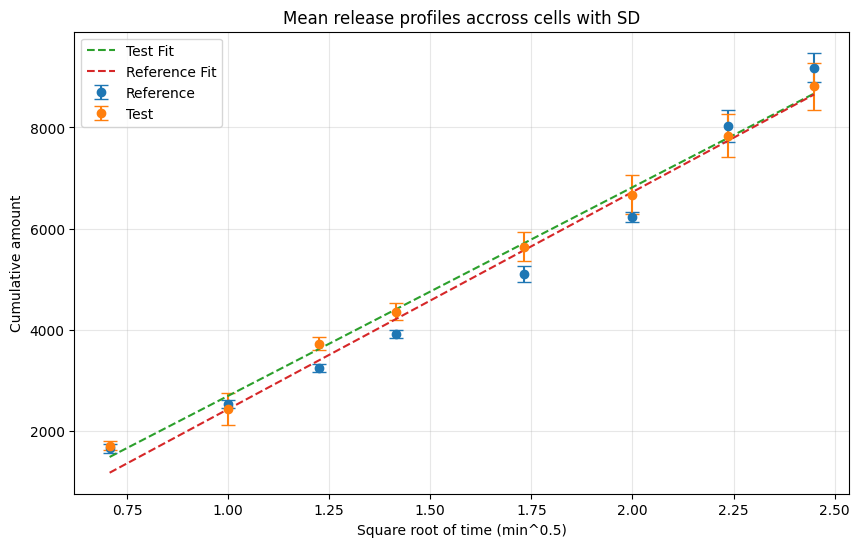

In [ ]:
# Create figure
plt.figure(figsize=(10, 6))

# Plot reference with error bars
plt.errorbar(ref_data['Sq. root of time'], ref_data['Mean'], yerr=ref_data['SD'], label='Reference', marker='o', linestyle='None', capsize=5)
# Plot test with error bars
plt.errorbar(test_data['Sq. root of time'], test_data['Mean'], yerr=test_data['SD'], label='Test', marker='o', linestyle='None', capsize=5)

# Add the regression lines for average release profiles
test_coef = np.polyfit(test_data['Sq. root of time'], test_data['Mean'], 1)
test_polyfit = np.poly1d(test_coef)

ref_coef = np.polyfit(ref_data['Sq. root of time'], ref_data['Mean'], 1)
ref_polyfit = np.poly1d(ref_coef)

# Labels and formatting
plt.xlabel('Square root of time (min^0.5)')
plt.ylabel('Cumulative amount')
plt.title('Mean release profiles accross cells with SD')
plt.plot(test_data['Sq. root of time'], test_polyfit(test_data['Sq. root of time']), label='Test Fit', linestyle='--')  # Add test fit line
plt.plot(ref_data['Sq. root of time'], ref_polyfit(ref_data['Sq. root of time']), label='Reference Fit', linestyle='--')  # Add reference fit line
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Calculate slope and R² for each cell
ref_slope = []
ref_rvalue = []
ref_pvalue = []
for col in ref_data_original.columns:  # Exclude 'Sq. root of time'
    slope, intercept, r_value, p_value, std_err = linregress(time_root, ref_data_original[col])
    ref_slope.append(slope)
    ref_rvalue.append(r_value**2)
    ref_pvalue.append(p_value)

test_slope = []
test_rvalue = []
test_pvalue = []
for col in test_data_original.columns:  # Exclude 'Sq. root of time'
    slope, intercept, r_value, p_value, std_err = linregress(time_root, test_data_original[col])
    test_slope.append(slope)
    test_rvalue.append(r_value**2)
    test_pvalue.append(p_value)

ref_slope_rsd = 100 * np.std(ref_slope) / np.mean(ref_slope)
test_slope_rsd = 100 * np.std(test_slope) / np.mean(test_slope)

for i in range(len(ref_slope)):
    print(f"Reference Cell {i+1}: Slope = {ref_slope[i]:.1f}, R² = {ref_rvalue[i]:.2f}, p-value = {ref_pvalue[i]:.4f}")
print(f"Reference Slope RSD%: {ref_slope_rsd:.2f}%\n")
for i in range(len(test_slope)):
    print(f"Test Cell {i+1}: Slope = {test_slope[i]:.1f}, R² = {test_rvalue[i]:.2f}, p-value = {test_pvalue[i]:.4f}")
print(f"Test Slope RSD%: {test_slope_rsd:.2f}%")

Reference Cell 1: Slope = 4071.5, R² = 0.98, p-value = 0.0000
Reference Cell 2: Slope = 4451.3, R² = 0.97, p-value = 0.0000
Reference Cell 3: Slope = 4373.3, R² = 0.97, p-value = 0.0000
Reference Cell 4: Slope = 4240.7, R² = 0.98, p-value = 0.0000
Reference Cell 5: Slope = 4302.8, R² = 0.97, p-value = 0.0000
Reference Cell 6: Slope = 4306.2, R² = 0.97, p-value = 0.0000
Reference Slope RSD%: 2.75%

Test Cell 1: Slope = 4240.1, R² = 0.98, p-value = 0.0000
Test Cell 2: Slope = 4205.5, R² = 0.99, p-value = 0.0000
Test Cell 3: Slope = 4193.3, R² = 0.98, p-value = 0.0000
Test Cell 4: Slope = 4013.5, R² = 0.99, p-value = 0.0000
Test Cell 5: Slope = 4167.8, R² = 0.98, p-value = 0.0000
Test Cell 6: Slope = 3919.2, R² = 0.99, p-value = 0.0000
Test Slope RSD%: 2.82%


In [11]:
# Extract the last row of the original data (cumulative amount at last time point)
time_points = len(ref_data_original.index.tolist())-1  # Last row index starting with 0
ref_cum_amount = ref_data_original.iloc[time_points:, :].values.flatten().tolist()
test_cum_amount = test_data_original.iloc[time_points:, :].values.flatten().tolist()
#print(time_points)
print(ref_cum_amount)
print(test_cum_amount)

[8746.8, 9122.9, 9308.8, 9085.7, 9640.3, 9204.4]
[8165.6, 8647.2, 9067.5, 8772.5, 9551.7, 8669.7]


In [12]:
ref_cell_count = ref_data_original.shape[1]
test_cell_count = test_data_original.shape[1]

ref_ln_slope = np.log(ref_slope)
test_ln_slope = np.log(test_slope)
ref_ln_cum = np.log(ref_cum_amount)
test_ln_cum = np.log(test_cum_amount)

# Create a dictionary to hold the cell-by-cell metrics
summary_dict = {
    'Cell_ID': [f'Ref_{i+1}' for i in range(ref_cell_count)] + [f'Test_{i+1}' for i in range(test_cell_count)],
    'Group': ['Reference']*ref_cell_count + ['Test']*test_cell_count,
    'Slope': np.concatenate([ref_slope, test_slope]),
    'R2': np.concatenate([ref_rvalue, test_rvalue]),
    'p value for slope': np.concatenate([ref_pvalue, test_pvalue]),
    'Cumulative': np.concatenate([ref_cum_amount, test_cum_amount]),
    # Can't add arrays so concatenate was used
    'Ln Slope': np.concatenate([ref_ln_slope, test_ln_slope]),
    'Ln Cumulative': np.concatenate([ref_ln_cum, test_ln_cum])
}

df_validation = pd.DataFrame(summary_dict)
# Pass/fail checks using np.where
df_validation['Linearity_Pass'] = np.where(df_validation['R2'] >= 0.9, 'Pass', 'Fail')
df_validation['Slope_Significant'] = np.where(df_validation['p value for slope'] < 0.05, 'Pass', 'Fail')

df_validation.head(2*ref_cell_count)

,Cell_ID,Group,Slope,R2,p value for slope,Cumulative,Ln Slope,Ln Cumulative,Linearity_Pass,Slope_Significant
0,Ref_1,Reference,4071.452621,0.982497,1.686718e-06,8746.8,8.311755,9.076443,Pass,Pass
1,Ref_2,Reference,4451.275812,0.968836,9.570519e-06,9122.9,8.400946,9.118543,Pass,Pass
2,Ref_3,Reference,4373.288468,0.972824,6.337248e-06,9308.8,8.383271,9.138715,Pass,Pass
3,Ref_4,Reference,4240.684408,0.979372,2.764426e-06,9085.7,8.352480,9.114457,Pass,Pass
4,Ref_5,Reference,4302.849701,0.965419,1.309429e-05,9640.3,8.367033,9.173708,Pass,Pass
5,Ref_6,Reference,4306.150830,0.973022,6.199003e-06,9204.4,8.367800,9.127437,Pass,Pass
6,Test_1,Test,4240.133824,0.975519,4.627430e-06,8165.6,8.352350,9.007685,Pass,Pass
7,Test_2,Test,4205.487828,0.993112,1.023684e-07,8647.2,8.344146,9.064991,Pass,Pass
8,Test_3,Test,4193.285184,0.984644,1.138207e-06,9067.5,8.341240,9.112452,Pass,Pass
9,Test_4,Test,4013.461571,0.993010,1.070118e-07,8772.5,8.297409,9.079377,Pass,Pass


In [13]:
# The mean squared error as it is caclualted in the one way ANOVA for the within group variability (MS_B)
display(Math(r'MS_B = \frac{\sum (Y_{T,i} - \bar{Y}_T)^2 + \sum (Y_{R,i} - \bar{Y}_R)^2}{n_T + n_R - 2}'))

# Confidence intervals from the lof transformed values, the SE Standard error is calculated from the pooled variance and degrees of freedom
display(Math(r'90\% CI = \exp\left( (\ln \bar{Y}_T - \ln \bar{Y}_R) \pm t_{0.10, r} \sqrt{MS_{B,ln} \left( \frac{1}{n_T} + \frac{1}{n_R} \right)} \right) \times 100'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [14]:
# The mean squared error as it is caclualted in the one way ANOVA for the within group variability (MS_B)
display(Math(r'MS_B = \frac{\sum (Y_{T,i} - \bar{Y}_T)^2 + \sum (Y_{R,i} - \bar{Y}_R)^2}{n_T + n_R - 2}'))
display(Math(r'MS_B = \frac{(n_T - 1)s_T^2 + (n_R - 1)s_R^2}{n_T + n_R - 2}'))
# Fieller's theorem
display(Math(r'g = \frac{t_{df,\alpha}^2 \cdot MS_B}{n_R \cdot \bar{Y}_R^2}'))
#Confidence interval from Fieller's theorem
display(Math(r'CI = \frac{1}{1-g} \left[ \frac{\bar{Y}_T}{\bar{Y}_R} \pm \frac{t_{df,\alpha}}{\bar{Y}_R} \sqrt{MS_B \left( \frac{1-g}{n_T} + \frac{(\bar{Y}_T/\bar{Y}_R)^2}{n_R} \right)} \right]'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [15]:
# Variances of ln transformed values for slope and cumulative amount
ref_lnslope_var = np.var(ref_ln_slope, ddof=1)
test_lnslope_var = np.var(test_ln_slope, ddof=1)
ref_lncum_var = np.var(ref_ln_cum, ddof=1)
test_lncum_var = np.var(test_ln_cum, ddof=1)
# Variances of untransformed slope values and cumulative amount
ref_slope_var = np.var(ref_slope, ddof=1)
test_slope_var = np.var(test_slope, ddof=1)
ref_cum_var = np.var(ref_cum_amount, ddof=1)
test_cum_var = np.var(test_cum_amount, ddof=1)

# T value for a 2 tail 90% confidence and degrees of freedom (nT + nR - 2)
n_T = len(test_slope)
n_R = len(ref_slope)
df = n_T + n_R - 2
t_value = t.ppf(0.95, df)  

print(f"Expansion t-value (90% CI, {df} df): {t_value:.4f}")

Expansion t-value (90% CI, 10 df): 1.8125


In [16]:
# Individual means for reference and test groups for slope and cumulative amount
ref_lnslope_mean = np.mean(ref_ln_slope)
test_lnslope_mean = np.mean(test_ln_slope)
ref_lncum_mean = np.mean(ref_ln_cum)
test_lncum_mean = np.mean(test_ln_cum)

# Geometric mean ratio (GMR) for slope and cumulative amount
slope_GMR = 100 * np.exp(test_lnslope_mean - ref_lnslope_mean)
cum_GMR = 100 * np.exp(test_lncum_mean - ref_lncum_mean)

# Pooled variance for log transformed slope and cumulative amount
pooled_var_slopeln = ((n_T - 1) * test_lnslope_var + (n_R - 1) * ref_lnslope_var) / df
pooled_var_cumln = ((n_T - 1) * test_lncum_var + (n_R - 1) * ref_lncum_var) / df
SE_slopeln = np.sqrt(pooled_var_slopeln * (1/n_T + 1/n_R))
SE_cumln = np.sqrt(pooled_var_cumln * (1/n_T + 1/n_R))
# The overall stanrd error can also be calculated from individual variances and sample sizes without pooling
SE_slopeln2 = np.sqrt((ref_lnslope_var / n_R) + (test_lnslope_var / n_T))

# Confidence interval limits for slope and cumulative amount using log transformed values
LL_slope_ln = (test_lnslope_mean - ref_lnslope_mean) - t_value * SE_slopeln
UL_slope_ln = (test_lnslope_mean - ref_lnslope_mean) + t_value * SE_slopeln
LL_cum_ln = (test_lncum_mean - ref_lncum_mean) - t_value * SE_cumln
UL_cum_ln = (test_lncum_mean - ref_lncum_mean) + t_value * SE_cumln

LCI_slope_ln = 100 * np.exp(LL_slope_ln)
UCI_slope_ln = 100 * np.exp(UL_slope_ln)
LCI_cum_ln = 100 * np.exp(LL_cum_ln)
UCI_cum_ln = 100 * np.exp(UL_cum_ln)

slopeln_equivalent = (LCI_slope_ln >= 90) and (UCI_slope_ln <= 111)
cumln_equivalent = (LCI_cum_ln >= 90) and (UCI_cum_ln <= 111)

print("-- Calculation for the log transformed values of slope and cumulative amount --")
print(f"Geometric Mean Ratio (GMR) for Slope: {slope_GMR:.4f}")
print(f"Geometric Mean Ratio (GMR) for Cumulative Amount: {cum_GMR:.4f}")
print(f"Lower 90%CI for Slope: {LCI_slope_ln:.4f}")
print(f"Upper 90%CI for Slope: {UCI_slope_ln:.4f}")
print(f"Equivalence Result for Slope: {'PASS' if slopeln_equivalent else 'FAIL'}")
print(f"Lower 90%CI for Cumulative Amount: {LCI_cum_ln:.4f}")
print(f"Upper 90%CI for Cumulative Amount: {UCI_cum_ln:.4f}")
print(f"Equivalence Result for Cumulative Amount: {'PASS' if cumln_equivalent else 'FAIL'}")



-- Calculation for the log transformed values of slope and cumulative amount --
Geometric Mean Ratio (GMR) for Slope: 96.0890
Geometric Mean Ratio (GMR) for Cumulative Amount: 95.8752
Lower 90%CI for Slope: 93.0398
Upper 90%CI for Slope: 99.2381
Equivalence Result for Slope: PASS
Lower 90%CI for Cumulative Amount: 91.6192
Upper 90%CI for Cumulative Amount: 100.3290
Equivalence Result for Cumulative Amount: PASS


In [17]:
# Individual means for reference and test groups for slope and cumulative amount
ref_slope_mean = np.mean(ref_slope)
test_slope_mean = np.mean(test_slope)
ref_cum_mean = np.mean(ref_cum_amount)
test_cum_mean = np.mean(test_cum_amount)

# Pooled variance for log transformed slope and cumulative amount which is equal to MSb from ANOVA
pooled_var_slope = ((n_T - 1) * test_slope_var + (n_R - 1) * ref_slope_var) / df
pooled_var_cum = ((n_T - 1) * test_cum_var + (n_R - 1) * ref_cum_var) / df

# g value for the Fieller's confidence interval calulation
g_value = (t_value**2 * pooled_var_slope) / (n_R * ref_slope_mean**2)
g_value_cum = (t_value**2 * pooled_var_cum) / (n_R * ref_cum_mean**2)

# Confidence limits for the ratio of means using Fieller's theorem
LCI_slope_fieller = (1/(1-g_value)) * ((test_slope_mean / ref_slope_mean) - (t_value/ ref_slope_mean) * np.sqrt(pooled_var_slope * (((1-g_value)/n_T) + (test_slope_mean/ref_slope_mean)**2 / n_R)))
UCI_slope_fieller = (1/(1-g_value)) * ((test_slope_mean / ref_slope_mean) + (t_value/ ref_slope_mean) * np.sqrt(pooled_var_slope * (((1-g_value)/n_T) + (test_slope_mean/ref_slope_mean)**2 / n_R)))

LCI_cum_fieller = (1/(1-g_value_cum)) * ((test_cum_mean / ref_cum_mean) - (t_value/ ref_cum_mean) * np.sqrt(pooled_var_cum * (((1-g_value_cum)/n_T) + (test_cum_mean/ref_cum_mean)**2 / n_R)))
UCI_cum_fieller = (1/(1-g_value_cum)) * ((test_cum_mean / ref_cum_mean) + (t_value/ ref_cum_mean) * np.sqrt(pooled_var_cum * (((1-g_value_cum)/n_T) + (test_cum_mean/ref_cum_mean)**2 / n_R)))

slope_equivalent = (LCI_slope_fieller >= 0.9) and (UCI_slope_fieller <= 1.11)
cum_equivalent = (LCI_cum_fieller >= 0.9) and (UCI_cum_fieller <= 1.11)

print("-- Calculation according to the Filler's theorem --")
print(f"g value for slope  by Fieller's theorem: {g_value:.4f}")
print(f"g value for cummulative amount by Fieller's theorem: {g_value_cum:.4f}")
print(f"Lower 90%CI for Slope (Fieller's): {100 * LCI_slope_fieller:.4f} %")
print(f"Upper 90%CI for Slope (Fieller's): {100 * UCI_slope_fieller:.4f} %")
print(f"Equivalence Result for Slope: {'PASS' if slope_equivalent else 'FAIL'}")
print(f"Lower 90%CI for Cumulative Amount (Fieller's): {100 * LCI_cum_fieller:.4f} %")
print(f"Upper 90%CI for Cumulative Amount (Fieller's): {100 * UCI_cum_fieller:.4f} %")
print(f"Equivalence Result for Cumulative Amount: {'PASS' if cum_equivalent else 'FAIL'}")

-- Calculation according to the Filler's theorem --
g value for slope  by Fieller's theorem: 0.0005
g value for cummulative amount by Fieller's theorem: 0.0010
Lower 90%CI for Slope (Fieller's): 93.0688 %
Upper 90%CI for Slope (Fieller's): 99.2071 %
Equivalence Result for Slope: PASS
Lower 90%CI for Cumulative Amount (Fieller's): 91.7004 %
Upper 90%CI for Cumulative Amount (Fieller's): 100.3775 %
Equivalence Result for Cumulative Amount: PASS
